In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    @tf.keras.utils.register_keras_serializable()
    def loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, K.epsilon(), 1.0 - K.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        focal_loss = weight * cross_entropy
        return tf.reduce_sum(focal_loss, axis=1)
    return loss


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks
model = keras.models.load_model("best_model.keras", custom_objects={"loss": categorical_focal_loss()})


In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,277,802 (31.58 MB)

 Trainable params: 1,174,120 (4.48 MB)

 Non-trainable params: 4,755,440 (18.14 MB)

 Optimizer params: 2,348,242 (8.96 MB)

8 Class Dataset

In [ ]:
class_names = ['Textiles', 'cardboard', 'glass', 'metal',
               'organic_waste', 'paper', 'plastic', 'trash']

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input
import cv2
import numpy as np

import matplotlib.pyplot as plt
def predict_image(img_path, model, class_names):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {predicted_class} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()

    return predicted_class


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


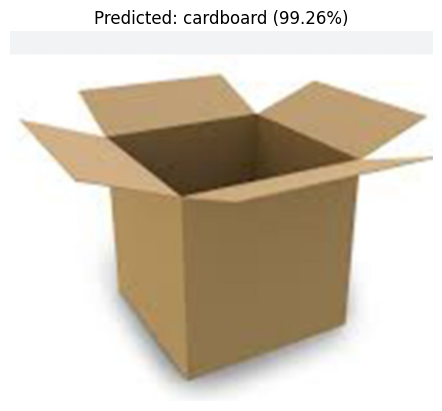

Predicted Class: cardboard


In [ ]:
image_path='/content/Screenshot (45).png'
predicted_class = predict_image(image_path, model, class_names)
print("Predicted Class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


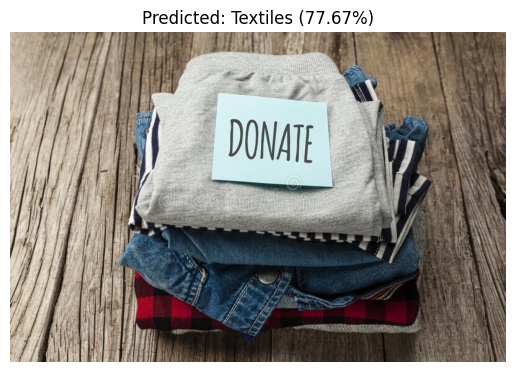

Predicted Class: Textiles


In [ ]:
image_path='/content/stack-old-clothes-to-discard-declutter-donate-recycling-fabric-cotton-198101748.jpg'
predicted_class = predict_image(image_path, model, class_names)
print("Predicted Class:", predicted_class)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 81.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

In [ ]:
import ultralytics
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 102MB/s]


In [ ]:
results = yolo_model('/content/Screenshot (46).png')
boxes = results[0].boxes.xyxy.cpu().numpy()  # x1, y1, x2, y2



image 1/1 /content/Screenshot (46).png: 640x576 1 traffic light, 1 bottle, 1 clock, 435.9ms
Speed: 10.9ms preprocess, 435.9ms inference, 37.9ms postprocess per image at shape (1, 3, 640, 576)



image 1/1 /content/Screenshot (46).png: 640x576 1 traffic light, 3 bottles, 1 clock, 548.8ms
Speed: 20.8ms preprocess, 548.8ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 576)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


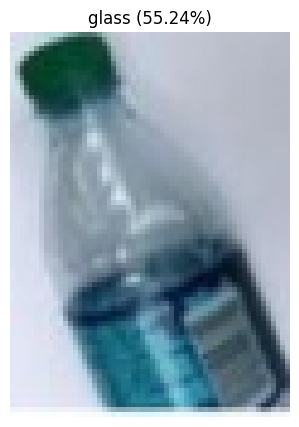

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


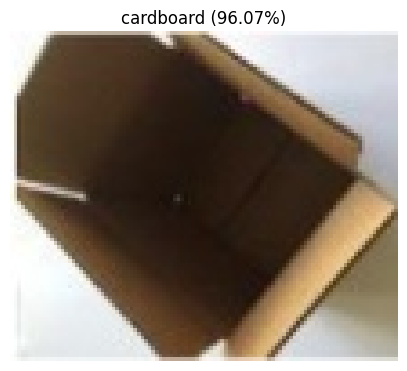

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


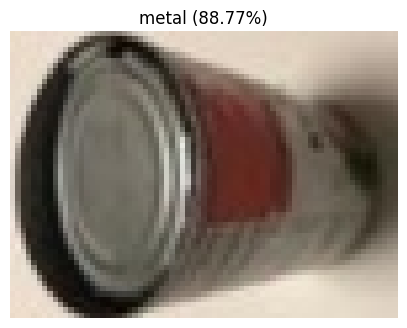

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


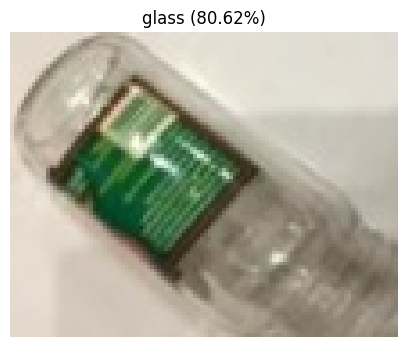

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


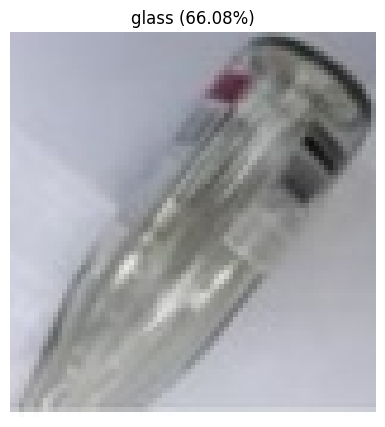

Detected 5 objects


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input
from ultralytics import YOLO
yolo_model = YOLO('yolov8n.pt')
image_path = '/content/Screenshot (46).png'
img = cv2.imread(image_path)
assert img is not None, "Image not found"
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = yolo_model(image_path, conf=0.2, iou=0.4)
os.makedirs("crops", exist_ok=True)

boxes = results[0].boxes.xyxy.cpu().numpy()
cropped_paths = []
for i, box in enumerate(boxes):
    x1, y1, x2, y2 = map(int, box)
    crop = img[y1:y2, x1:x2]
    crop_path = f"crops/crop_{i}.jpg"
    cv2.imwrite(crop_path, crop)
    cropped_paths.append(crop_path)
def predict_image(img_path, model, class_names):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    return predicted_class, confidence

class_names = [ 'Textiles', 'cardboard', 'glass', 'metal', 'organic_waste', 'paper', 'plastic', 'trash']

for path in cropped_paths:
    predicted_class, confidence = predict_image(path, model, class_names)

    crop_img = cv2.imread(path)
    crop_img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5, 5))
    plt.imshow(crop_img_rgb)
    plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
    plt.axis('off')
    plt.show()
print(f"Detected {len(boxes)} objects")


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks
model_sec = keras.models.load_model('/content/best_model (1).keras')

In [ ]:
model_sec.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,752,986 (10.50 MB)

 Trainable params: 165,000 (644.53 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,002 (1.26 MB)

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling 

#Detection Using YOLO

4 Class Dataset

In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model
from ultralytics import YOLO

yolo_model = YOLO('yolov8n.pt')
model = load_model('/content/best_model (1).keras')
class_names = ['Food_Waste', 'Hazardous_Waste', 'Recyclable_Waste', 'Residual_Waste']

def predict_image(img_array, model, class_names, threshold=0.5):
    img = cv2.resize(img_array, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img, verbose=0)
    max_conf = np.max(prediction)

    if max_conf >= threshold:
        predicted_class = class_names[np.argmax(prediction)]
        return predicted_class, max_conf
    else:
        return None, max_conf




In [ ]:
def compute_iou(box1, box2):
    x1, y1, x2, y2 = box1
    xx1 = max(x1, box2[0])
    yy1 = max(y1, box2[1])
    xx2 = min(x2, box2[2])
    yy2 = min(y2, box2[3])

    inter_area = max(0, xx2 - xx1) * max(0, yy2 - yy1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area

    return inter_area / union_area if union_area > 0 else 0


In [ ]:
def filter_boxes(boxes, iou_threshold=0.5):
    filtered_boxes = []
    for box in boxes:
        keep = True
        for fbox in filtered_boxes:
            if compute_iou(box, fbox) > iou_threshold:
                keep = False
                break
        if keep:
            filtered_boxes.append(box)
    return filtered_boxes


In [ ]:
def process_image(image_path, classify_threshold=0.5, iou_filter_threshold=0.5):
    img = cv2.imread(image_path)
    assert img is not None, f"Image {image_path} not found."

    results = yolo_model(image_path, conf=0.2, iou=0.4, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    print(f"Initially detected {len(boxes)} boxes")

    # Filter overlapping boxes
    filtered_boxes = filter_boxes(boxes, iou_threshold=iou_filter_threshold)
    print(f"Filtered to {len(filtered_boxes)} non-overlapping boxes")

    for i, box in enumerate(filtered_boxes):
        x1, y1, x2, y2 = map(int, box)
        crop = img[y1:y2, x1:x2]

        predicted_class, confidence = predict_image(crop, model, class_names, threshold=classify_threshold)

        if predicted_class:
            print(f"Crop {i}: {predicted_class} ({confidence:.2f})")
            plt.figure(figsize=(4, 4))
            plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
            plt.title(f"{predicted_class} ({confidence*100:.2f}%)")
            plt.axis('off')
            plt.show()
        else:
            print(f"Crop {i}: Low confidence ({confidence:.2f}), skipped.")


Detected 3 objects in /content/Screenshot 2025-06-04 170320.png
Crop 0: Recyclable_Waste (0.93)


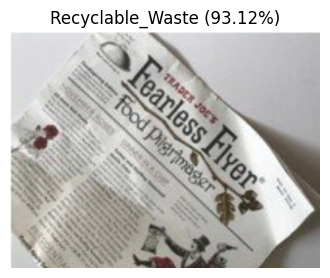

Crop 1: Recyclable_Waste (0.68)


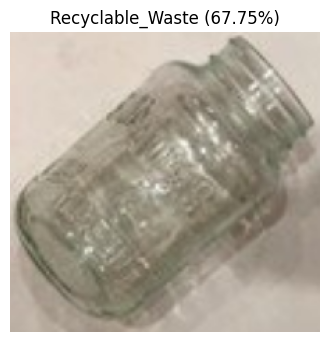

Crop 2: Recyclable_Waste (0.50)


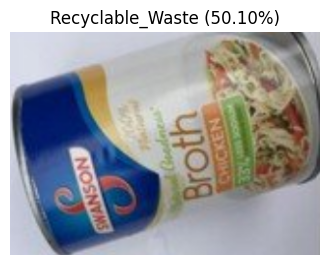

In [ ]:
image_path = '/content/Screenshot 2025-06-04 170320.png'
process_image(image_path, classify_threshold=0.4)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/Classification_Dataset/New folder (2)/Classification_Dataset.zip'
extract_path = '/content/waste_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


Detected 1 objects in /content/waste_data/Classification_Dataset/Hazardous_Waste/IMG_6306_JPG.rf.09b66a13a96fa6bba2e32867aa36494b.jpg
Crop 0: Hazardous_Waste (0.81)


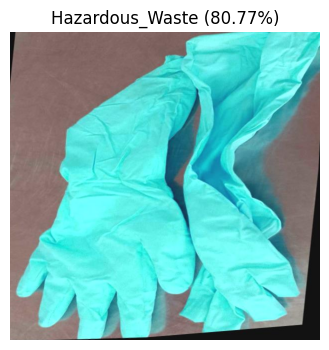

In [ ]:
image_path='/content/waste_data/Classification_Dataset/Hazardous_Waste/IMG_6306_JPG.rf.09b66a13a96fa6bba2e32867aa36494b.jpg'
process_image(image_path, classify_threshold=0.5)

Initially detected 2 boxes
Filtered to 1 non-overlapping boxes
Crop 0: Food_Waste (0.84)


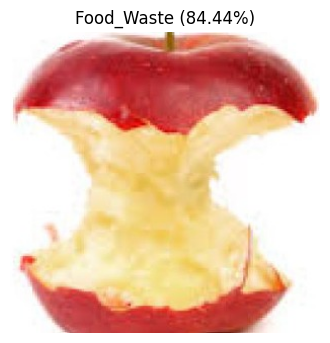

In [ ]:
image_path='/content/WhatsApp Image 2025-07-22 at 14.11.34.jpeg'
process_image(image_path, classify_threshold=0.5)